##### I. Setup

In [1]:
!pip uninstall -y pyspark pyspark-connect dataproc-spark-connect

Found existing installation: pyspark 4.0.2
Uninstalling pyspark-4.0.2:
  Successfully uninstalled pyspark-4.0.2
Found existing installation: dataproc-spark-connect 1.1.0
Uninstalling dataproc-spark-connect-1.1.0:
  Successfully uninstalled dataproc-spark-connect-1.1.0


In [2]:
!pip install -q pyspark==3.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 14.4 MB/s eta 0:00:00


In [3]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] += ":/usr/lib/jvm/java-17-openjdk-amd64/bin"

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("DataCleaning") \
    .getOrCreate()

spark

In [5]:
import os
from pyspark.sql import SparkSession, DataFrame
from google.colab import files
from pyspark.sql.functions import *
from pyspark.sql.types import TimestampType
from functools import reduce

In [6]:
from google.colab import files
files= files.upload()

Saving OnlineRetail.csv to OnlineRetail.csv


##### II. Load data

In [7]:
df = spark.read.csv("OnlineRetail.csv", header=True, inferSchema=True)
df.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows



##### III. Data Profiling, Anomaly Detection, and Data Cleaning

###### 3.1 Check the number of columns and rows

In [8]:
# Check the number of columns and rows
print("Number of columns: ", len(df.columns))
print("Number of rows: ", df.count())

Number of columns:  8
Number of rows:  541909


###### 3.2 Abnormal 1: Check and Correct data type

In [9]:
# Check schema
df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [10]:
# Convert datatype of InvoiceDate to timestamp
df_cleaned = df.withColumn("InvoiceDate", to_timestamp("InvoiceDate", "M/d/yyyy H:mm"))

# Re-check schema
df_cleaned.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



###### 3.3 Abnormal 2: Check and handle missing values

In [11]:
# Check for missing values in original data
missing_values = df_cleaned.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df_cleaned.columns
])
missing_values.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



- `Description`: 1,454 --> remove since it is hard to guess the product description
- `CustomerID`: 135,080 --> might keep them, change `null` value into `Unknown`

In [12]:
df_cleaned.filter(df.Description.isNull()).select("StockCode").distinct().count()

960

In [13]:
missing_stockcodes = (
    df_cleaned
    .filter(col("Description").isNull())
    .select("StockCode")
    .distinct()
    .rdd.flatMap(lambda x: x)
    .collect()
)

In [14]:
# Delete the null values in Description
df_cleaned = df_cleaned.filter(df_cleaned.Description.isNotNull())

# Change the value in CustomerID into "Unknown" for null values
df_cleaned = df_cleaned.withColumn("CustomerID", when(df_cleaned.CustomerID.isNull(), "Unknown").otherwise(df_cleaned.CustomerID))

In [15]:
# Re-check for missing values in the cleaned data
missing_values = df_cleaned.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df_cleaned.columns
])
missing_values.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|          0|       0|          0|        0|         0|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



###### 3.4 Abnormal 3: Check and handle duplicate rows

In [16]:
# Check the number of duplicate rows
duplicate_count = df_cleaned.count() - df_cleaned.dropDuplicates().count()
print("Number of duplicate rows: ", duplicate_count)

Number of duplicate rows:  5268


In [17]:
# Drop duplicate rows
df_cleaned = df_cleaned.dropDuplicates()

In [18]:
# Re-check the number of duplicate rows
duplicate_count = df_cleaned.count() - df_cleaned.dropDuplicates().count()
print("Number of duplicate rows: ", duplicate_count)

Number of duplicate rows:  0


###### 3.5 Abnormal 4: Handle negative Quantity and UnitPrice

**Check the number of cancelled order:**

The InvoiceNo starts with C (has negative Quantity)

In [30]:
from pyspark.sql import functions as F

# Cancelled orders
cancel = df_cleaned.filter(F.col("InvoiceNo").startswith("C"))

# Negative quantity but NOT cancelled
neg_qty_non_cancel = df_cleaned.filter(
    (~F.col("InvoiceNo").startswith("C")) &
    (F.col("Quantity") < 0)
)

# Negative unit price
neg_price = df_cleaned.filter(F.col("UnitPrice") < 0)

In [31]:
print("Cancelled orders:", cancel.count())
print("Negative qty but NOT cancelled:", neg_qty_non_cancel.count())
print("Negative unit price:", neg_price.count())

Cancelled orders: 9251
Negative qty but NOT cancelled: 474
Negative unit price: 2


In [35]:
from pyspark.sql import functions as F

df_cleaned = df_cleaned.filter(
    F.col("InvoiceNo").startswith("C") |
    (
        (~F.col("InvoiceNo").startswith("C")) &
        (F.col("Quantity") >= 0) &
        (F.col("UnitPrice") >= 0)
    )
)
print(df_cleaned.count())

534711


In [33]:
cancelled_df = df_cleaned.filter(
    F.col("InvoiceNo").startswith("C")
)
print(cancelled_df.count())

9251


###### 3.6 Abnormal 5: Identify abnormal `StockCode` - `Description` pairs that are not actual products

**Check abnormal StockCodes**

In [36]:
excluded_stockcodes = ["POST", "DOT", "M", "C2", "BANK CHARGES","S", "B", "AMAZONFEE",
                       "gift_0001_10", "gift_0001_20","gift_0001_30","gift_0001_40","gift_0001_50"]

# Identify rows with exclued StockCode
df_excluded = df_cleaned.filter(col("StockCode").isin(excluded_stockcodes))

# Show distinct excluded StockCode - Description pairs
df_excluded.select("StockCode", "Description").distinct().show(truncate=False)

+------------+-----------------------------------+
|StockCode   |Description                        |
+------------+-----------------------------------+
|POST        |POSTAGE                            |
|DOT         |DOTCOM POSTAGE                     |
|gift_0001_40|Dotcomgiftshop Gift Voucher �40.00 |
|C2          |CARRIAGE                           |
|gift_0001_30|Dotcomgiftshop Gift Voucher �30.00 |
|BANK CHARGES|Bank Charges                       |
|M           |Manual                             |
|AMAZONFEE   |AMAZON FEE                         |
|gift_0001_50|Dotcomgiftshop Gift Voucher �50.00 |
|gift_0001_20|to push order througha s stock was |
|gift_0001_20|Dotcomgiftshop Gift Voucher �20.00 |
|S           |SAMPLES                            |
|gift_0001_10|Dotcomgiftshop Gift Voucher �10.00 |
|B           |Adjust bad debt                    |
+------------+-----------------------------------+



**Handle abnormal `StockCode` and `Description` pairs that are not actual products**

In [37]:
df_cleaned = df_cleaned.filter(~col("StockCode").isin(excluded_stockcodes))

In [38]:
# Re-check the abnormal stock code
df_excluded = df_cleaned.filter(col("StockCode").isin(excluded_stockcodes))
df_excluded.select("StockCode", "Description").distinct().show(truncate=False)

+---------+-----------+
|StockCode|Description|
+---------+-----------+
+---------+-----------+



##### IV. Data Cleaning results

In [39]:
# The number of rows before cleaning
rows_before_cleaning = df.count()
print(f"Number of rows before cleaning: {rows_before_cleaning}")

Number of rows before cleaning: 541909


In [40]:
# Check the number of rows after cleaning
rows_after_cleaning = df_cleaned.count()
print(f"Number of rows after cleaning: {rows_after_cleaning}")

Number of rows after cleaning: 531875


##### V. Feature Engineering

###### 5.1 Create Recency, Frequency, and Monetary (RFM) features

Convert InvoiceDate to DateType

In [41]:
from pyspark.sql.functions import col, to_date

# Convert InvoiceDate from string to DateType
df_fe = df_cleaned.withColumn("InvoiceDate", to_date(col("InvoiceDate"), "M/d/yyyy H:mm"))
df_fe.printSchema()
df_fe.show(5)

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: date (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)

+---------+---------+--------------------+--------+-----------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-----------+---------+----------+--------------+
|   536415|    22951|60 CAKE CASES DOL...|       2| 2010-12-01|     0.55|     12838|United Kingdom|
|   536488|    22909|SET OF 20 VINTAGE...|       1| 2010-12-01|     0.85|     17897|United Kingdom|
|   536592|    22665|RECIPE BOX BLUE S...|       1| 2010-12-01|     5.91|   Unknown|United Kingdom|
|   536600|   84029G|KNITTED UNION FLA...|       6| 2010-12-02|  

In [42]:
# Get the max date of the dataset
max_date = df_fe.agg(max("InvoiceDate")).collect()[0][0]
max_date

datetime.date(2011, 12, 9)

In [43]:
# Calculate recency
recency_df = df_fe.groupBy("CustomerID").agg(
    datediff(lit(max_date), max("InvoiceDate")).alias("Recency")
)
recency_df.show()

+----------+-------+
|CustomerID|Recency|
+----------+-------+
|     16250|    261|
|     15574|    177|
|     15555|     12|
|     15271|      7|
|     17714|    320|
|     17686|      7|
|     13865|     58|
|     14157|     19|
|     13610|     12|
|     13772|     33|
|     13282|     18|
|     12394|     63|
|     16320|    172|
|     13192|     95|
|     17757|      1|
|     17551|    359|
|     13187|    337|
|     16549|     10|
|     12637|     67|
|     15052|    319|
+----------+-------+
only showing top 20 rows



In [44]:
# Calculate frequency (number of transactions per customer)
frequency_df = df_fe.groupBy("CustomerID").agg(
    countDistinct("InvoiceNo").alias("Frequency")
)
frequency_df.show()

+----------+---------+
|CustomerID|Frequency|
+----------+---------+
|     15555|       20|
|     15574|        4|
|     14157|        3|
|     17686|        7|
|     13610|        9|
|     13865|        4|
|     16250|        2|
|     17714|        1|
|     13282|        6|
|     15271|       16|
|     16320|        2|
|     12394|        2|
|     13192|        2|
|     15634|        1|
|     14204|        1|
|     18130|        4|
|     17427|        1|
|     17506|        2|
|     15269|        1|
|     16504|        1|
+----------+---------+
only showing top 20 rows



In [45]:
# Calculate Monetary (Total money spent by customer)
monetary_df = df_fe.withColumn("TotalPrice", col("Quantity") * col("UnitPrice")) \
    .groupBy("CustomerID") \
    .agg(round(sum("TotalPrice"), 3).alias("Monetary"))
monetary_df.show()

+----------+--------+
|CustomerID|Monetary|
+----------+--------+
|     13610| 1065.88|
|     15555| 4745.75|
|     15271| 2472.09|
|     15574|  675.64|
|     13282| 1047.84|
|     14157|  392.44|
|     16250|  389.44|
|     12394| 1080.48|
|     17686| 5739.46|
|     16320| 1038.46|
|     13865|  501.56|
|     13772| 1122.63|
|     17714|   153.0|
|     13192|  911.94|
|     18130| 1045.74|
|     16504|  465.88|
|     17506|  294.29|
|     12847|  843.64|
|     14887|  1862.0|
|     14204|  150.61|
+----------+--------+
only showing top 20 rows



In [46]:
# Join all RFM features
dfs = [recency_df, frequency_df, monetary_df]
rfm_df = reduce(lambda df1, df2: df1.join(df2, "CustomerID"), dfs)
rfm_df.show()

+----------+-------+---------+--------+
|CustomerID|Recency|Frequency|Monetary|
+----------+-------+---------+--------+
|     15555|     12|       20| 4745.75|
|     15574|    177|        4|  675.64|
|     14157|     19|        3|  392.44|
|     17686|      7|        7| 5739.46|
|     13610|     12|        9| 1065.88|
|     13865|     58|        4|  501.56|
|     16250|    261|        2|  389.44|
|     17714|    320|        1|   153.0|
|     13282|     18|        6| 1047.84|
|     15271|      7|       16| 2472.09|
|     16320|    172|        2| 1038.46|
|     12394|     63|        2| 1080.48|
|     13192|     95|        2|  911.94|
|     15634|     17|        1|  243.55|
|     14204|      2|        1|  150.61|
|     18130|      8|        4| 1045.74|
|     17427|     71|        1|   100.8|
|     17506|     70|        2|  294.29|
|     15269|     23|        1|   408.8|
|     16504|     25|        1|  465.88|
+----------+-------+---------+--------+
only showing top 20 rows



In [47]:
from pyspark.sql.functions import mean

rfm_df.select(
    mean("Recency").alias("Mean_Recency"),
    mean("Frequency").alias("Mean_Frequency"),
    mean("Monetary").alias("Mean_Monetary")
).show()


+-----------------+-----------------+------------------+
|     Mean_Recency|   Mean_Frequency|     Mean_Monetary|
+-----------------+-----------------+------------------+
|91.66888175985335|5.375114573785518|2235.9512060036664|
+-----------------+-----------------+------------------+



In [48]:
# Define thresholds based on the mean values
recency_threshold = 95
frequency_threshold = 7

# Create a new column 'Churn' based on the thresholds
rfm_df = rfm_df.withColumn(
    "Churn",
    when((col("Recency") > recency_threshold) & (col("Frequency") <= frequency_threshold), 1).otherwise(0)
)

# Show the resulting DataFrame with Churn column
rfm_df.select("CustomerID", "Recency", "Frequency", "Monetary", "Churn").show(50)

+----------+-------+---------+--------+-----+
|CustomerID|Recency|Frequency|Monetary|Churn|
+----------+-------+---------+--------+-----+
|     15555|     12|       20| 4745.75|    0|
|     15574|    177|        4|  675.64|    1|
|     14157|     19|        3|  392.44|    0|
|     17686|      7|        7| 5739.46|    0|
|     13610|     12|        9| 1065.88|    0|
|     13865|     58|        4|  501.56|    0|
|     16250|    261|        2|  389.44|    1|
|     17714|    320|        1|   153.0|    1|
|     13282|     18|        6| 1047.84|    0|
|     15271|      7|       16| 2472.09|    0|
|     16320|    172|        2| 1038.46|    1|
|     12394|     63|        2| 1080.48|    0|
|     13192|     95|        2|  911.94|    0|
|     15634|     17|        1|  243.55|    0|
|     14204|      2|        1|  150.61|    0|
|     18130|      8|        4| 1045.74|    0|
|     17427|     71|        1|   100.8|    0|
|     17506|     70|        2|  294.29|    0|
|     15269|     23|        1|   4

In [49]:
# join data
final_df= df_fe.join(rfm_df,on= 'CustomerID', how= 'left')
final_df.show()

+----------+---------+---------+--------------------+--------+-----------+---------+--------------+-------+---------+--------+-----+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|InvoiceDate|UnitPrice|       Country|Recency|Frequency|Monetary|Churn|
+----------+---------+---------+--------------------+--------+-----------+---------+--------------+-------+---------+--------+-----+
|     12427|   536861|    22301|COFFEE MUG CAT + ...|       6| 2010-12-03|     2.55|       Germany|     11|        5|  582.37|    0|
|     12433|   536532|    22534|MAGIC DRAWING SLA...|      24| 2010-12-01|     0.42|        Norway|      0|        7|13375.87|    0|
|     12838|   536415|    22951|60 CAKE CASES DOL...|       2| 2010-12-01|     0.55|United Kingdom|     33|        2|  671.95|    0|
|     12915|   536707|   85132C|CHARLIE AND LOLA ...|       1| 2010-12-02|     9.95|United Kingdom|    148|        2|  363.65|    1|
|     13013|   536947|   84534B|FAIRY CAKE NOTEBO...|      24| 2010-1

# 📊 Customer Growth & Retention Analysis

## 📌 Context  
The dataset is an e-commerce transactional retail dataset where each row represents a product-level transaction within an invoice (InvoiceNo–StockCode granularity). It includes key attributes such as `CustomerID`, `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `UnitPrice`, `InvoiceDate`, and `Country`.

This structure allows the data to be analyzed at multiple levels:
- **Transaction level** (invoice-product interactions)
- **Product level** (sales performance by SKU)
- **Customer level** (behavioral patterns over time)

By aggregating this dataset, we can derive meaningful insights into customer purchasing behavior, product performance, and market dynamics across time.

---

## ❗ Problem  
The main objective of this analysis is to understand the drivers of business growth and customer retention in an e-commerce setting.

Key questions include:
- Is the business truly growing in terms of revenue and orders, or is growth driven by a small subset of customers/products?
- What factors contribute to customer retention and churn?
- Which products and markets are driving sustainable growth?
- How does customer behavior evolve over time in terms of purchase frequency and spending?

Additionally, it is important to distinguish between:
- **Real growth** (new customer acquisition and expanding customer base)
- **Repeat-driven growth** (revenue generated from existing customers only)

---

## 🚀 Approach (G-3Ps Framework)

The analysis follows the **G-3Ps framework: Growth – Product – Place – People**, providing a structured view from business performance to customer behavior.

---

### 📈 1. Growth  
This layer focuses on core business performance and overall revenue dynamics.

Key metrics include:
- Total Orders
- Total Revenue
- Average Order Value (AOV)
- Average Basket Size (items per order)
- Average Order Frequency per Customer
- Order Time Window (time gap between purchases)
- Temporal trends:
  - Daily / weekly patterns
  - Monthly, quarterly, and yearly trends (MoM, QoQ, YoY)

👉 Objective: Evaluate whether growth is consistent, seasonal, or driven by specific events or segments.

---

### 🧾 2. Product  
This layer analyzes product performance and its contribution to business outcomes.

Key analyses include:
- **Hero Products**: top revenue-generating products
- **Losing Products**: products with declining sales trends
- **Churn-related Products**: products commonly purchased by churned customers
- **Non-churn Favorites**: products associated with retained customers
- Product sales trends over time (volume and revenue-based)

👉 Objective: Understand product mix contribution and identify which products drive or hinder growth.

---

### 🌍 3. Place (Market)  
This layer examines geographic performance and market expansion opportunities.

Key analyses include:
- Revenue and order distribution by country
- Month-over-month (MoM) and year-over-year (YoY) growth by market
- Identification of high-growth and declining markets

👉 Objective: Identify key markets for expansion and underperforming regions requiring strategic attention.

---

### 👥 4. People (Customer)  
This layer focuses on customer lifecycle and retention behavior.

Key analyses include:
- New Customers (first-time purchasers in the latest period)
- Returning Customers
- Churned Customers (inactive over a defined period)
- RFM segmentation (Recency, Frequency, Monetary)
- Customer retention vs churn trends over time

👉 Objective: Understand customer lifecycle stages and identify drivers of churn and retention.

---

### 🧺 5. Market Basket Analysis (FP-Growth)

To uncover hidden relationships between products and customer purchasing behavior, **Market Basket Analysis** is performed using the **FP-Growth algorithm**.

The objective is to identify products that are frequently bought together and extract meaningful association rules.

Key steps include:
- Aggregating transactions at the invoice level to form item baskets
- Encoding product lists per transaction
- Applying FP-Growth to discover frequent itemsets
- Generating association rules based on support, confidence, and lift

Key outputs:
- Frequently co-purchased product sets
- Cross-selling opportunities
- Product bundling strategies
- Recommendation system signals (e.g., “Customers who bought X also bought Y”)

👉 Objective: Improve revenue through bundling strategies, recommendation systems, and optimized product placement.

---

### ⚠️ 6. Churn Prediction & Key Driver Analysis

To understand customer retention behavior, a **Churn Prediction model** is developed to identify customers who are likely to stop purchasing in the future.

#### 📌 Churn Definition:
A customer is considered churned if they have not made any purchase within a defined time window (e.g., last 60–90 days).

---

#### 🤖 Modeling Approach:
A supervised learning model is built using customer-level features such as:
- Recency (time since last purchase)
- Frequency (number of transactions)
- Monetary value (total spend)
- Average order value
- Purchase frequency trends
- Basket size behavior
- Product diversity
- Country / market segment

Common models used:
- Logistic Regression (baseline interpretability)
- Random Forest / Gradient Boosting (non-linear patterns)
- Feature importance via SHAP or model-based importance

---

#### 🔍 Key Factor Identification:
To understand **why customers churn**, feature importance and explainability techniques are applied.

Typical churn drivers include:
- High Recency (long inactivity period)
- Low Frequency (infrequent purchases)
- Declining monetary contribution
- Low product diversity
- Weak engagement with repeat purchases
- Market-specific behavioral drop-off

---

👉 Objective:
- Predict at-risk customers before churn happens
- Identify key behavioral signals leading to churn
- Enable targeted retention strategies (discounts, re-engagement campaigns, personalized offers)

---

## 🎯 Final Outcome of Advanced Analytics Layer

These two components extend the analysis beyond descriptive insights:

- **FP-Growth → reveals “what products are connected”**
- **Churn Prediction → reveals “which customers are at risk and why”**

Together, they enable:
- Data-driven cross-selling strategies
- Proactive customer retention
- Revenue optimization through behavioral targeting

### Metrics/ Term Definition
---

## 📏 Metrics & Term Definitions

This section defines the key metrics and business terms used throughout the analysis to ensure consistency in interpretation and reporting.

---

### 📈 Growth Metrics

- **Total Orders**  
  Number of unique invoices (`InvoiceNo`) within a given time period. Each invoice represents a completed purchase transaction.

- **Total Revenue**  
  Sum of transaction value computed as:  
  `Revenue = Quantity × UnitPrice`

- **Average Order Value (AOV)**  
  Average revenue generated per order:  
  `AOV = Total Revenue / Total Orders`

- **Average Basket Size**  
  Average number of items per order:  
  `Basket Size = Total Quantity / Total Orders`

- **Order Frequency per Customer**  
  Average number of unique orders placed by each customer within a defined period.

- **Order Time Window**  
  Average time gap between consecutive purchases made by the same customer.

---

### 👥 Customer Metrics (RFM-Based)

- **Recency (R)**  
  Number of days since the customer's most recent purchase.

- **Frequency (F)**  
  Number of unique transactions (`InvoiceNo`) made by a customer.

- **Monetary (M)**  
  Total spending of a customer:  
  `Monetary = Σ (Quantity × UnitPrice)`

---

### ⚠️ Customer Lifecycle Labels

- **New Customer**  
  A customer who makes their first-ever purchase within the analysis period.

- **Returning Customer**  
  A customer who has made more than one purchase.

- **Churned Customer**  
  A customer who has not made any purchase within a defined inactivity window (e.g., 60–90 days).

---

### 🧺 Market Basket Metrics (FP-Growth)

- **Itemset (Frequent Itemset)**  
  A group of products that frequently appear together in the same transaction.

- **Support**  
  Proportion of transactions that contain a given itemset.

- **Confidence**  
  Probability that a customer buys product B given they bought product A.

- **Lift**  
  Measure of how much more likely products are purchased together compared to random chance.

---

### ⚠️ Churn Prediction Metrics

- **Churn Probability**  
  Model-generated probability that a customer will become inactive.

- **Feature Importance**  
  Contribution of each feature (e.g., Recency, Frequency, Monetary) to churn prediction.

- **Key Drivers of Churn**  
  Behavioral factors that significantly increase churn risk, such as:
  - High Recency
  - Low Frequency
  - Declining Monetary value
  - Low engagement patterns

---

### Executive Summary

### **Growth**


In [54]:
final_df= final_df.withColumn("day_of_week", F.date_format("InvoiceDate", "EEEE")) \
       .withColumn("month", F.month("InvoiceDate")) \
       .withColumn("year", F.year("InvoiceDate")) \
       .withColumn("month_year", F.date_format("InvoiceDate", "yyyy-MM")) \
       .withColumn("quarter_year", F.concat(
           F.year("InvoiceDate"),
           F.lit("-Q"),
           F.quarter("InvoiceDate")
       ))

In [55]:
final_df.show(5)

+----------+---------+---------+--------------------+--------+-------------------+---------+-------+-------+---------+--------+-----+-----------+-----+----+----------+------------+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|Country|Recency|Frequency|Monetary|Churn|day_of_week|month|year|month_year|quarter_year|
+----------+---------+---------+--------------------+--------+-------------------+---------+-------+-------+---------+--------+-----+-----------+-----+----+----------+------------+
|     12347|   556201|    23162|REGENCY TEA STRAINER|       8|2011-06-09 00:00:00|     3.75|Iceland|      2|        7|  4310.0|    0|   Thursday|    6|2011|   2011-06|     2011-Q2|
|     12347|   549222|    16008|SMALL FOLDING SCI...|      24|2011-04-07 00:00:00|     0.25|Iceland|      2|        7|  4310.0|    0|   Thursday|    4|2011|   2011-04|     2011-Q2|
|     12347|   562032|    23308|SET OF 60 VINTAGE...|      24|2011-08-02 00:00:00|     0.55|Ice

In [77]:
def format_km(value):
    """
    Format number into K (thousands) or M (millions)
    """
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return f"{value:.0f}"

In [61]:
final_df = final_df.withColumn(
    "Revenue",
    F.col("Quantity") * F.col("UnitPrice")
)
total_revenue = final_df.agg(F.sum("Revenue")).collect()[0][0]
print(f'Total Revenue: {total_revenue}')

Total Revenue: 9757691.062999792


In [62]:
total_orders = final_df.select("InvoiceNo").distinct().count()
print(f'Total Orders: {total_orders}')

Total Orders: 23457


In [63]:
order_df = final_df.groupBy("InvoiceNo").agg(
    F.sum("Revenue").alias("order_revenue")
)

AOV = order_df.agg(F.avg("order_revenue")).collect()[0][0]
print(f'Average Order Value: {AOV}')

Average Order Value: 415.9820549516179


In [64]:
basket_df = df.groupBy("InvoiceNo").agg(
    F.sum("Quantity").alias("items_per_order")
)

avg_basket_size = basket_df.agg(
    F.avg("items_per_order")
).collect()[0][0]
print(f'Average Basket Size: {avg_basket_size}')

Average Basket Size: 227.2325105512214


In [65]:
customer_freq = final_df.groupBy("CustomerID").agg(
    F.countDistinct("InvoiceNo").alias("frequency")
)

avg_order_frequency = customer_freq.agg(
    F.avg("frequency")
).collect()[0][0]
print(f'Average Order Frequency: {avg_order_frequency}')

Average Order Frequency: 5.375114573785518


In [69]:
from pyspark.sql.window import Window
w = Window.partitionBy("CustomerID").orderBy("InvoiceDate")

df_gap = final_df.withColumn(
    "prev_date",
    F.lag("InvoiceDate").over(w)
).withColumn(
    "time_gap_days",
    F.datediff("InvoiceDate", F.col("prev_date"))
)

avg_time_window = df_gap.agg(
    F.avg("time_gap_days")
).collect()[0][0]
print(f'Average Time Gap Between Orders: {avg_time_window}')

Average Time Gap Between Orders: 1.105186432131273


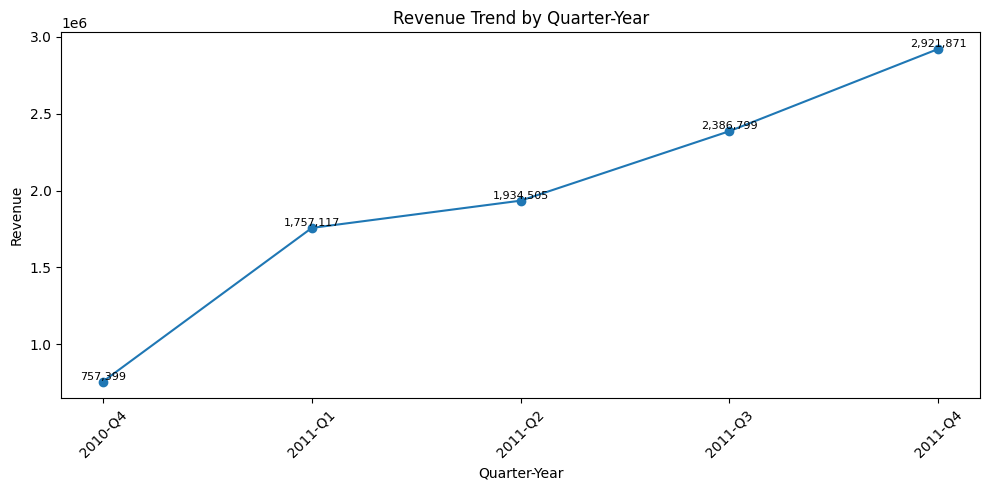

In [70]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
# 3. Aggregate revenue by quarter-year
qtr_df = final_df.groupBy("quarter_year").agg(
    F.sum("Revenue").alias("Revenue")
).orderBy("quarter_year")

# 4. Convert to pandas for plotting
pdf = qtr_df.toPandas()

# 5. Save CSV
pdf.to_csv("revenue_quarterly_trend.csv", index=False)

# 6. Plot
plt.figure(figsize=(10,5))

plt.plot(pdf["quarter_year"], pdf["Revenue"], marker="o")

# No grid lines (important requirement)
plt.grid(False)

# Data labels
for x, y in zip(pdf["quarter_year"], pdf["Revenue"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=8)

plt.xticks(rotation=45)
plt.title("Revenue Trend by Quarter-Year")
plt.xlabel("Quarter-Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

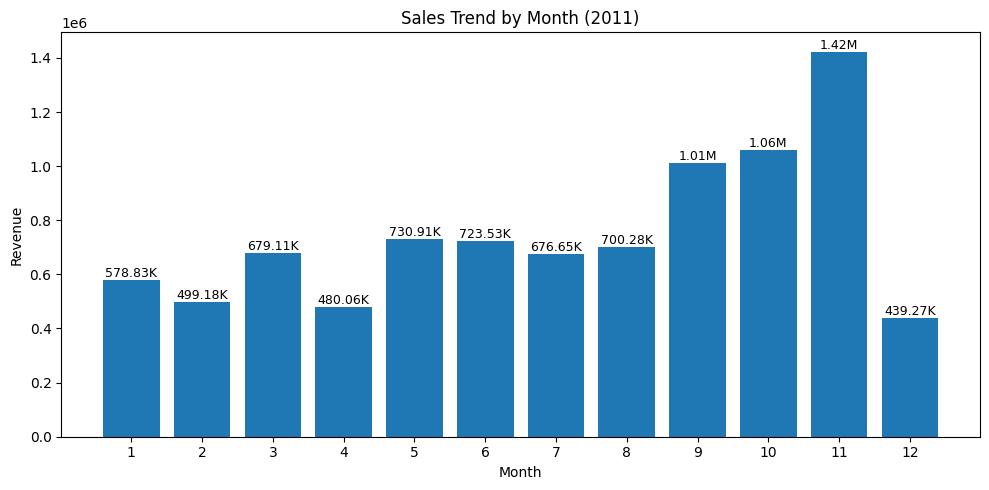

In [79]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# 1. Filter year
df_2011 = final_df.filter(F.year("InvoiceDate") == 2011)

# 2. Revenue (nếu chưa có)
df_2011 = df_2011.withColumn(
    "Revenue",
    F.col("Quantity") * F.col("UnitPrice")
)

# 3. Monthly aggregation
monthly_df = df_2011.groupBy(
    F.month("InvoiceDate").alias("month")
).agg(
    F.sum("Revenue").alias("Revenue")
).orderBy("month")

pdf = monthly_df.toPandas().sort_values("month")

# 4. Save CSV
pdf.to_csv("sales_trend_monthly_2011.csv", index=False)

# 5. Plot
plt.figure(figsize=(10,5))

plt.bar(pdf["month"], pdf["Revenue"])

plt.grid(False)

# 6. Y-axis labels using your function
for x, y in zip(pdf["month"], pdf["Revenue"]):
    plt.text(x, y, format_km(y), ha="center", va="bottom", fontsize=9)

plt.xticks(range(1,13))

plt.title("Sales Trend by Month (2011)")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [86]:
df_sep_oct_nov = final_df.filter(
    (F.year("InvoiceDate") == 2011) &
    (F.month("InvoiceDate").isin([9,10,11]))
)

In [89]:
from pyspark.sql.window import Window

df_sep_oct_nov = df_sep_oct_nov.withColumn(
    "week_of_month",
    F.ceil(F.dayofmonth("InvoiceDate") / 7)
)

In [90]:
weekly_df = df_sep_oct_nov.groupBy(
    "month",
    "week_of_month"
).agg(
    F.sum("Revenue").alias("Revenue")
).orderBy("month", "week_of_month")

In [91]:
pdf = weekly_df.toPandas()

In [92]:
sept = pdf[pdf["month"] == 9]
oct = pdf[pdf["month"] == 10]
nov= pdf[pdf["month"] == 11]

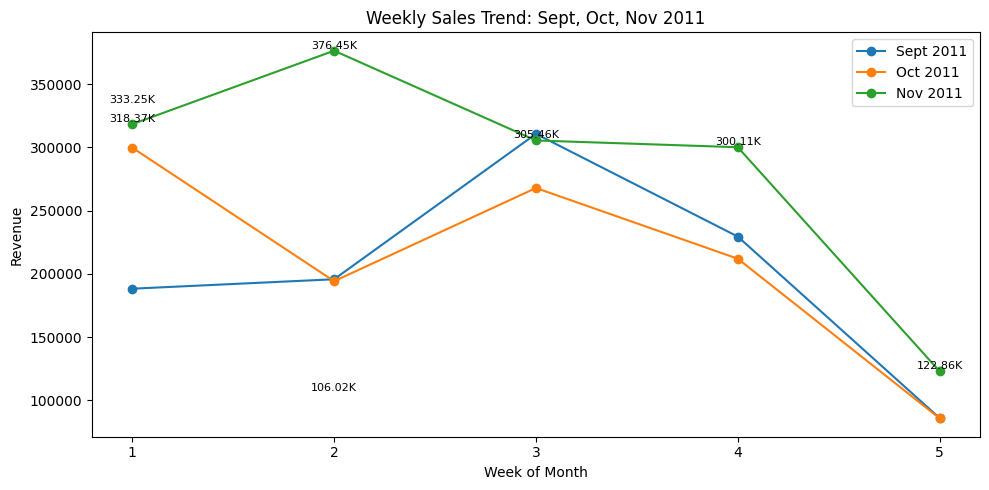

In [96]:
plt.figure(figsize=(10,5))

plt.plot(sept["week_of_month"], sept["Revenue"], marker="o", label="Sept 2011")
plt.plot(oct["week_of_month"], oct["Revenue"], marker="o", label="Oct 2011")
plt.plot(nov["week_of_month"], nov["Revenue"], marker="o", label="Nov 2011")

plt.grid(False)

# labels using your format_km
for x, y in zip(nov["week_of_month"], nov["Revenue"]):
    plt.text(x, y, format_km(y), ha="center", va="bottom", fontsize=8)

for x, y in zip(dec["week_of_month"], dec["Revenue"]):
    plt.text(x, y, format_km(y), ha="center", va="bottom", fontsize=8)

plt.title("Weekly Sales Trend: Sept, Oct, Nov 2011")
plt.xlabel("Week of Month")
plt.ylabel("Revenue")
plt.xticks([1,2,3,4,5])

plt.legend()
plt.tight_layout()
plt.show()

In [120]:
df_2011 = final_df.filter(final_df.year == 2011)

In [121]:
from pyspark.sql.functions import sum as _sum

weekly_trend = (
    df_2011
    .groupBy("quarter_year", "week_of_month")
    .agg(_sum("Revenue").alias("weekly_revenue"))
    .orderBy("quarter_year", "week_of_month")
)

In [122]:
pdf = weekly_trend.toPandas()

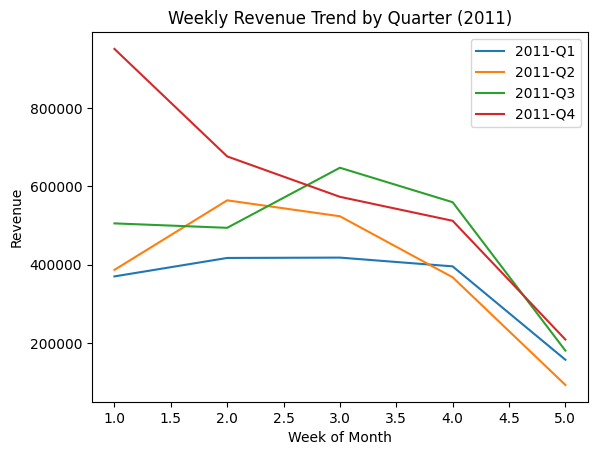

In [123]:
import matplotlib.pyplot as plt

for q in pdf['quarter_year'].unique():
    subset = pdf[pdf['quarter_year'] == q]
    plt.plot(subset['week_of_month'], subset['weekly_revenue'], label=q)

plt.xlabel("Week of Month")
plt.ylabel("Revenue")
plt.title("Weekly Revenue Trend by Quarter (2011)")
plt.legend()
plt.show()

In [98]:
df_nov = final_df.filter(
    (F.year("InvoiceDate") == 2011) &
    (F.month("InvoiceDate") == 11)
)

In [99]:
df_nov = df_nov.withColumn(
    "week_of_month",
    F.ceil(F.dayofmonth("InvoiceDate") / 7)
)

In [100]:
df_nov = df_nov.withColumn(
    "day_of_week",
    F.date_format("InvoiceDate", "EEEE")
)

In [102]:
week_day_df = df_nov.groupBy(
    "week_of_month",
    "day_of_week"
).agg(
    F.sum("Revenue").alias("Revenue")
)

In [104]:
pdf = week_day_df.toPandas()

In [105]:
pivot = pdf.pivot(
    index="day_of_week",
    columns="week_of_month",
    values="Revenue"
).fillna(0)

In [106]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = pivot.reindex(day_order)

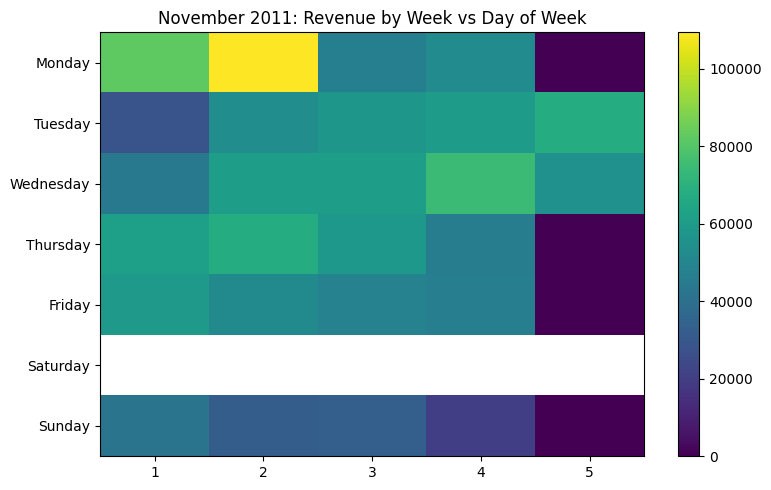

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.imshow(pivot, aspect="auto")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title("November 2011: Revenue by Week vs Day of Week")

plt.colorbar()

plt.tight_layout()
plt.show()

In [112]:
final_df = final_df.withColumn("week_of_month",
    F.ceil(F.dayofmonth("InvoiceDate") / 7)
)

In [113]:
agg_df = final_df.groupBy(
    "month",
    "week_of_month",
    "day_of_week"
).agg(
    F.sum("Revenue").alias("Revenue")
)

In [114]:
pdf = agg_df.toPandas()

In [115]:
nov = pdf[pdf["month"] == 11]
others = pdf[pdf["month"] != 11]

In [116]:
nov_focus = nov[
    (nov["week_of_month"] == 2) &
    (nov["day_of_week"] == "Monday")
]

others_focus = others[
    (others["week_of_month"] == 2) &
    (others["day_of_week"] == "Monday")
]

In [117]:
nov_value = nov_focus["Revenue"].sum()
others_avg = others_focus["Revenue"].mean()

print("Nov Week2 Monday:", nov_value)
print("Other months avg Week2 Monday:", others_avg)
print("Lift:", nov_value / others_avg)

Nov Week2 Monday: 109395.93000000001
Other months avg Week2 Monday: 26968.117272727264
Lift: 4.056491185264595


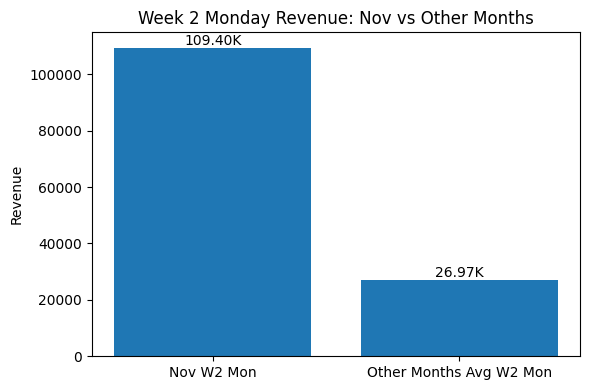

In [118]:
import matplotlib.pyplot as plt

labels = ["Nov W2 Mon", "Other Months Avg W2 Mon"]
values = [nov_value, others_avg]

plt.figure(figsize=(6,4))

plt.bar(labels, values)

plt.grid(False)

for x, y in zip(labels, values):
    plt.text(x, y, format_km(y), ha="center", va="bottom")

plt.title("Week 2 Monday Revenue: Nov vs Other Months")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### AOV Trends

### Number Of Items Trends

### Executive Summary Of Growth

### Product

In [127]:
top_products = (
    final_df
    .groupBy("StockCode", "Description")
    .agg(_sum("Revenue").alias("total_revenue"))
    .orderBy(col("total_revenue").desc())
)

top_products.show(10)

+---------+--------------------+------------------+
|StockCode|         Description|     total_revenue|
+---------+--------------------+------------------+
|    22423|REGENCY CAKESTAND...|164459.48999999973|
|    47566|       PARTY BUNTING| 98243.88000000043|
|   85123A|WHITE HANGING HEA...| 97659.93999999974|
|   85099B|JUMBO BAG RED RET...| 92175.79000000047|
|    23084|  RABBIT NIGHT LIGHT| 66661.62999999993|
|    22086|PAPER CHAIN KIT 5...| 63715.24000000025|
|    84879|ASSORTED COLOUR B...|58792.420000000464|
|    79321|       CHILLI LIGHTS| 53746.65999999993|
|    23298|      SPOTTY BUNTING| 42030.67000000007|
|    22386|JUMBO BAG PINK PO...| 41584.42999999988|
+---------+--------------------+------------------+
only showing top 10 rows



In [128]:
top_products_nov = (
    nov_df
    .groupBy("StockCode", "Description")
    .agg(_sum("Revenue").alias("total_revenue"))
    .orderBy(col("total_revenue").desc())
)

top_products_nov.show(10)

+---------+--------------------+------------------+
|StockCode|         Description|     total_revenue|
+---------+--------------------+------------------+
|    23084|  RABBIT NIGHT LIGHT| 34343.76999999993|
|    22086|PAPER CHAIN KIT 5...|28853.540000000008|
|   85123A|WHITE HANGING HEA...|14113.899999999987|
|    22197|      POPCORN HOLDER|13961.940000000004|
|    22910|PAPER CHAIN KIT V...|12816.789999999986|
|    22423|REGENCY CAKESTAND...|          12772.98|
|    79321|       CHILLI LIGHTS|11475.070000000003|
|   85099B|JUMBO BAG RED RET...|11456.130000000005|
|    23355|HOT WATER BOTTLE ...|          11436.52|
|    23344|JUMBO BAG 50'S CH...|10881.900000000005|
+---------+--------------------+------------------+
only showing top 10 rows



In [133]:
week2_nov = nov_df.filter(col("week_of_month") == 2)

top_products_week2 = (
    week2_nov
    .groupBy("StockCode", "Description")
    .agg(_sum("Revenue").alias("total_revenue"))
    .orderBy(col("total_revenue").desc())
)

top_products_week2.show(20)

+---------+--------------------+------------------+
|StockCode|         Description|     total_revenue|
+---------+--------------------+------------------+
|    22086|PAPER CHAIN KIT 5...| 8182.809999999996|
|    23084|  RABBIT NIGHT LIGHT|  6547.52999999999|
|   85099B|JUMBO BAG RED RET...| 4910.290000000002|
|    22197|      POPCORN HOLDER| 4395.299999999999|
|    23344|JUMBO BAG 50'S CH...| 3711.720000000001|
|    22910|PAPER CHAIN KIT V...|3628.7499999999986|
|    23203|JUMBO BAG VINTAGE...|3609.7400000000007|
|    84879|ASSORTED COLOUR B...|3108.5899999999997|
|    21137|BLACK RECORD COVE...|2956.2999999999997|
|    23313|VINTAGE CHRISTMAS...|           2952.49|
|    23581|JUMBO BAG PAISLEY...| 2783.829999999999|
|    22114|HOT WATER BOTTLE ...|2780.2499999999995|
|    22158|3 HEARTS HANGING ...|2732.4199999999983|
|   85123A|WHITE HANGING HEA...|2518.7999999999993|
|    23355|HOT WATER BOTTLE ...|           2312.97|
|    22866|HAND WARMER SCOTT...| 2299.869999999999|
|    23201| 

In [131]:
pdf_all = top_products.limit(20).toPandas()
pdf_nov = top_products_nov.limit(20).toPandas()
pdf_week2 = top_products_week2.limit(20).toPandas()

In [132]:
top_all = set([row["StockCode"] for row in top_products.limit(20).collect()])
top_nov = set([row["StockCode"] for row in top_products_nov.limit(20).collect()])
top_week2 = set([row["StockCode"] for row in top_products_week2.limit(20).collect()])

print("Common (All vs Nov):", top_all.intersection(top_nov))
print("Common (Nov vs Week2):", top_nov.intersection(top_week2))
print("Unique Week2:", top_week2 - top_nov)

Common (All vs Nov): {'23284', '85123A', '22197', '84879', '21137', '22423', '79321', '22086', '22114', '85099B', '23084'}
Common (Nov vs Week2): {'23355', '23581', '85123A', '23203', '22197', '22910', '23313', '84879', '21137', '22112', '79321', '22086', '22114', '85099B', '23344', '23084'}
Unique Week2: {'22158', '22866', '23201', '22865'}


### Place

### People